<a href="https://colab.research.google.com/github/jagadishkrishna/Meachine-Learning-Lab-Experiments/blob/main/CSE%20Kaggle%20-%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import files
uploaded = files.upload()

Saving accounts.csv to accounts.csv


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

In [8]:
df = pd.read_csv("accounts.csv")

In [9]:
df.head()

,account_id,customer_id,branch_id,account_type,balance,open_date,status
0,1,11749,141,Current,95902.00,2019-10-20,Active
1,2,47716,43,Current,13261.61,2026-02-03,Active
2,3,56143,90,Savings,26495.92,2020-10-19,Active
3,4,29193,113,Salary,74682.72,2012-02-22,Active
4,5,49907,28,Current,40419.01,2007-01-03,Active


In [10]:
df.shape

(95000, 7)

In [11]:
df.columns

Index(['account_id', 'customer_id', 'branch_id', 'account_type', 'balance',
       'open_date', 'status'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95000 entries, 0 to 94999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   account_id    95000 non-null  int64  
 1   customer_id   95000 non-null  int64  
 2   branch_id     95000 non-null  int64  
 3   account_type  95000 non-null  object 
 4   balance       95000 non-null  float64
 5   open_date     95000 non-null  object 
 6   status        95000 non-null  object 
dtypes: float64(1), int64(3), object(3)
memory usage: 5.1+ MB


In [13]:
df.isnull().sum()

,0
account_id,0
customer_id,0
branch_id,0
account_type,0
balance,0
open_date,0
status,0


In [14]:
df.describe()

,account_id,customer_id,branch_id,balance
count,95000.000000,95000.000000,95000.000000,95000.000000
mean,47500.500000,29991.208179,75.450695,45761.236422
std,27424.282124,17264.584944,43.295402,45306.411751
min,1.000000,1.000000,1.000000,500.360000
25%,23750.750000,15114.750000,38.000000,13551.047500
50%,47500.500000,30000.000000,75.000000,31768.655000
75%,71250.250000,44910.000000,113.000000,63337.515000
max,95000.000000,60000.000000,150.000000,539198.590000


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.nunique()

,0
account_id,95000
customer_id,47640
branch_id,150
account_type,5
balance,94538
open_date,7821
status,3


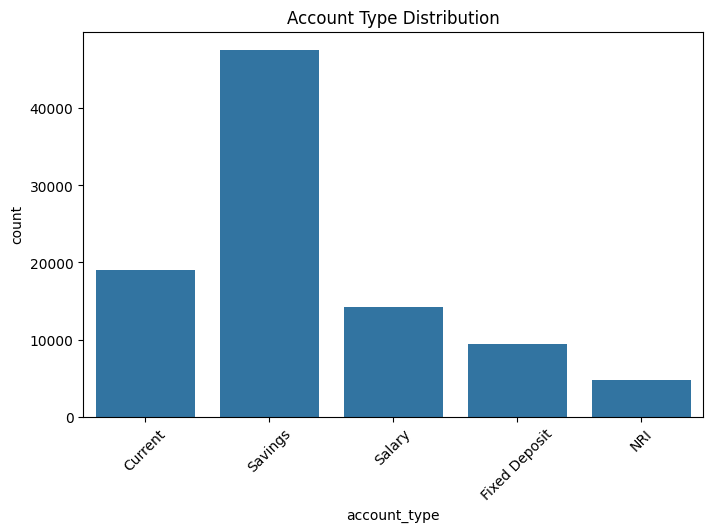

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(x='account_type', data=df)
plt.title("Account Type Distribution")
plt.xticks(rotation=45)
plt.show()

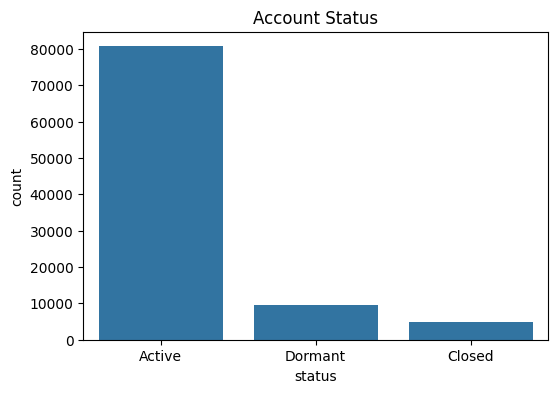

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x='status', data=df)
plt.title("Account Status")
plt.show()

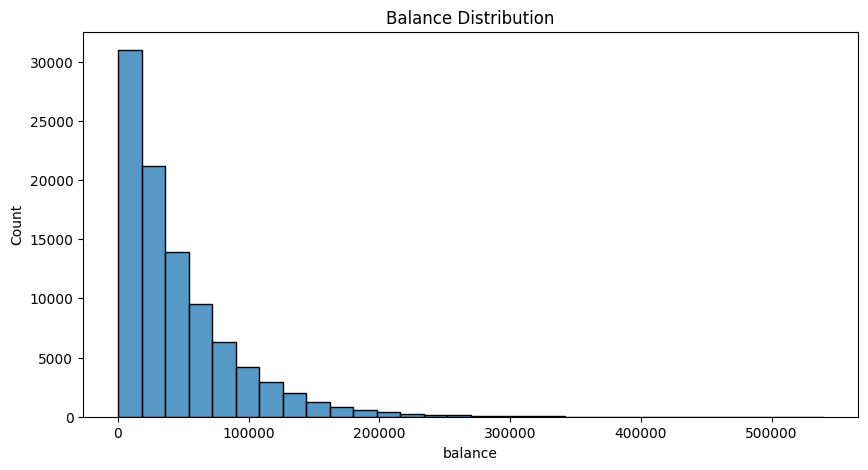

In [19]:
plt.figure(figsize=(10,5))
sns.histplot(df['balance'], bins=30)
plt.title("Balance Distribution")
plt.show()

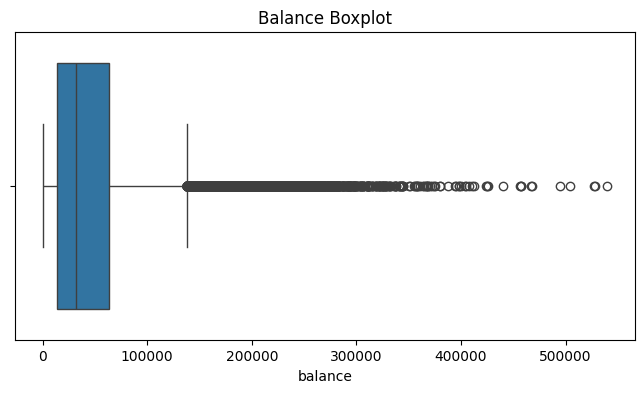

In [20]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['balance'])
plt.title("Balance Boxplot")
plt.show()

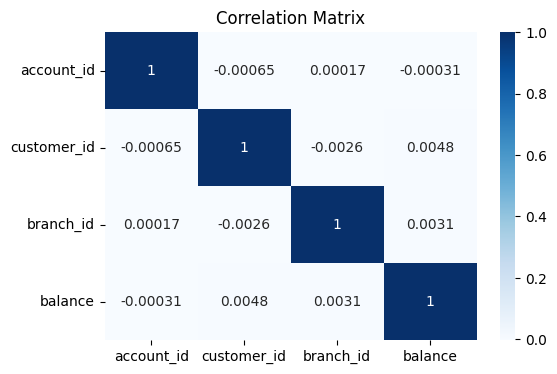

In [21]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues')
plt.title("Correlation Matrix")
plt.show()

In [22]:
df['open_date'] = pd.to_datetime(df['open_date'])

In [23]:
df['year'] = df['open_date'].dt.year

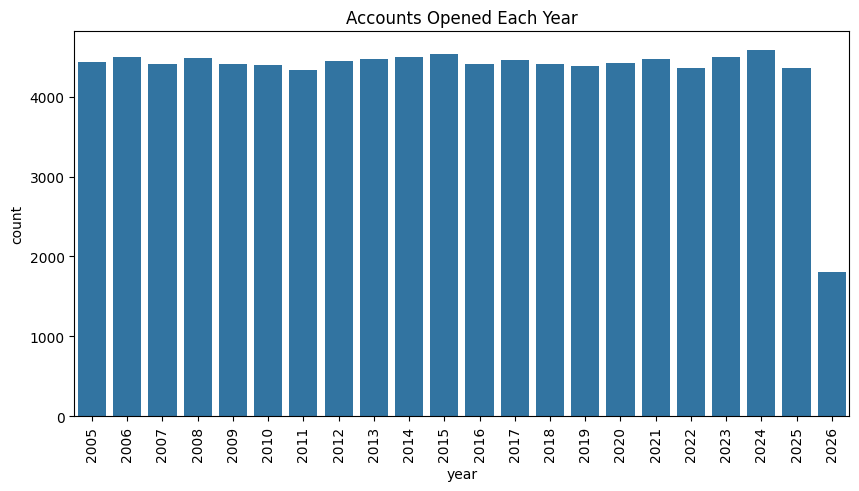

In [24]:
plt.figure(figsize=(10,5))
sns.countplot(x='year', data=df)
plt.xticks(rotation=90)
plt.title("Accounts Opened Each Year")
plt.show()

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['account_type'] = le.fit_transform(df['account_type'])
df['status'] = le.fit_transform(df['status'])

In [26]:
X = df.drop(['status','open_date'], axis=1)
y = df['status']

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [29]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [30]:
y_pred = model.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8494736842105263
              precision    recall  f1-score   support

           0       0.85      1.00      0.92     16141
           1       0.00      0.00      0.00       932
           2       0.40      0.00      0.00      1927

    accuracy                           0.85     19000
   macro avg       0.42      0.33      0.31     19000
weighted avg       0.76      0.85      0.78     19000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
